In [1]:
import os
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import scipy
import torch
from sklearn import metrics

import pickle
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
import itertools
from tqdm import tqdm

import importlib
import utils
import utils_CNV
warnings.filterwarnings('ignore')

/admin/software/anaconda/1.11.1/envs/jupyter/bin/python


In [2]:
importlib.reload(utils_CNV)
importlib.reload(utils)
from utils_CNV import *
from utils import *

In [3]:
distance_ranges = {
    'short': (0, 17),
    'mid': (17, 45),
    'long': (45, 98),
    'ultra': (98, 200)
}

In [4]:
chrom_sizes = pd.read_csv(
    "/data1/lesliec/carolw/genome/hg38/hg38.chrom.sizes",
    sep="\t",
    header=None,
    names=["chr", "size"]
)

In [6]:
#basal1: TCGA-BH-A0E0
#basal2: TCGA-A2-A0YJ
#basal3: TCGA-S3-AA0Z
#basal4: TCGA-AO-A124
#GBM6:TCGA-81-5910
#GBM7:TCGA-06-A5U0
cnv = get_sample_cnv_segments(
    "/data1/lesliec/carolw/data_raw/chromafold_metadata/ASCAT_ploidy_normalized.txt",
    "TCGA-A2-A0YJ"
)

print(cnv.head())

  Chromosome     Start       End  Relative_Copy_Number
0       chr1     13116  36146550              0.599437
1       chr1  36147779  42329635              0.799249
2       chr1  42332094  47636449              0.999062
3       chr1  47637459  49094186              1.198874
4       chr1  49095735  61526061              0.999062


In [7]:
bins = annotate_bins_with_cnv(cnv, chrom_sizes)

In [12]:
bins

,chrom,start,end,copy_number,CNA_status
0,chr1,0,10000,1.000000,neutral
1,chr1,10000,20000,0.599437,deletion
2,chr1,20000,30000,0.599437,deletion
3,chr1,30000,40000,0.599437,deletion
4,chr1,40000,50000,0.599437,deletion
...,...,...,...,...,...
308832,chrY,57180000,57190000,1.000000,neutral
308833,chrY,57190000,57200000,1.000000,neutral
308834,chrY,57200000,57210000,1.000000,neutral
308835,chrY,57210000,57220000,1.000000,neutral


In [8]:
amplified_bins = bins[bins["CNA_status"] == "amplification"]

# View first few
len(amplified_bins)

9172

In [15]:
amplified_bins[amplified_bins["chrom"] == "chr17"]

,chrom,start,end,copy_number,CNA_status
252798,chr17,37130000,37140000,2.197936,amplification
252799,chr17,37140000,37150000,2.197936,amplification
252800,chr17,37150000,37160000,2.197936,amplification
252801,chr17,37160000,37170000,2.197936,amplification
252802,chr17,37170000,37180000,2.197936,amplification
...,...,...,...,...,...
253103,chr17,40180000,40190000,5.994370,amplification
253104,chr17,40190000,40200000,5.994370,amplification
253105,chr17,40200000,40210000,5.994370,amplification
253106,chr17,40210000,40220000,5.994370,amplification


In [9]:
mixed_bins = bins[bins["CNA_status"] == "mixed"]

# View first few
len(mixed_bins)

0

In [10]:
ct = 'BRCA-C147AAD5-A8F1-41D5-8709-21820BE50902-X005-S01-B1-T1_H3K27ac'
ct2= 'BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1'
genome = 'hg38'
mod = 'chromafold_CTCFmotif'

#basal1:BRCA-7C6A3AE4-E2EA-42B3-B3F1-81C19E6F2170-X004-S01-B1-T1_H3K27ac
#basal1:BRCA_7C6A3AE4_E2EA_42B3_B3F1_81C19E6F2170_X005_S02_B1_T1
#basal2:BRCA-C147AAD5-A8F1-41D5-8709-21820BE50902-X005-S01-B1-T1_H3K27ac
#basal2: BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1
#basal3: BRCA-CB96A542-7AC1-4FEC-A5D2-458D8EEDC6C4-X001-S01-B1-T1_H3K27ac
#basal3: BRCA_CB96A542_7AC1_4FEC_A5D2_458D8EEDC6C4_X013_S06_B1_T1
#basal4: BRCA-DD69EDE9-142D-46E2-AA06-58D07D3230FB-X002-S04-B1-T1_H3K27ac
#basal4: BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1
#GBM6: GBMx-9976F952-23A5-431A-A431-01E544324A26-X015-S02-B1-T1_H3K27ac
#GBM6:GBMx_9976F952_23A5_431A_A431_01E544324A26_X010_S05_B1_T1
#GBM7: GBMx-A90B18B6-6056-46D1-BF4E-70710236B8DD-X015-S07-B1-T1_H3K27ac
#GBM7: GBMx_A90B18B6_6056_46D1_BF4E_70710236B8DD_X006_S04_B1_T1

In [11]:
# load ground truth HiChIP

zscore_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/zvalue/{ct}_hic_zscore_dict.p"
)

pval_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/qvalue/{ct}_hic_qvalue_dict.p"
)

with open(zscore_path, "rb") as f:
    hicdc = pickle.load(f)

with open(pval_path, "rb") as f:
    pval = pickle.load(f)

In [27]:
chrom_list = [str(i) for i in range(1, 23)]
results = evaluate_predictions_by_chrom(
    chrom_list,
    hicdc=hicdc,
    pval=pval,
    ct2=ct2,
    mod=mod,
    pred_base_path=f"/data1/lesliec/carolw/projects/chromafold/predictions/BRCA-chan_1_3k/{ct2}",
    plot=False
)


===== Chromosome 1 =====


100%|██████████████████████████████████| 24595/24595 [00:01<00:00, 13012.13it/s]



===== Chromosome 10 =====


100%|██████████████████████████████████| 13079/13079 [00:00<00:00, 29059.50it/s]



===== Chromosome 11 =====


...

100%|██████████████████████████████████| 15613/15613 [00:00<00:00, 19889.01it/s]



===== Chromosome 8 =====


100%|██████████████████████████████████| 14213/14213 [00:00<00:00, 21915.56it/s]



===== Chromosome 9 =====


100%|██████████████████████████████████| 13539/13539 [00:00<00:00, 22977.81it/s]


In [28]:
bin_acc_df = create_bin_diag_accuracy_all(results, bins)
#bin_acc_df = create_bin_diag_accuracy(results, bins, metric='pearson')
#bin_acc_df = create_bin_diag_accuracy(results, bins, metric='prc')
# Check
print(bin_acc_df.head())
# For each bin, store a list of diagonal accuracies

  chrom  start    end                                           roc_list  \
0  chr1      0  10000  [0.9084624293774184, 0.931193425393515, 0.9211...   
1  chr1  10000  20000  [0.9084624293774184, 0.931193425393515, 0.9211...   
2  chr1  20000  30000  [0.9084624293774184, 0.931193425393515, 0.9211...   
3  chr1  30000  40000  [0.9084624293774184, 0.931193425393515, 0.9211...   
4  chr1  40000  50000  [0.9084624293774184, 0.931193425393515, 0.9211...   

                                        pearson_list  \
0  [0.574646515813856, 0.5949285581591216, 0.6118...   
1  [0.574646515813856, 0.5949285581591216, 0.6118...   
2  [0.574646515813856, 0.5949285581591216, 0.6118...   
3  [0.574646515813856, 0.5949285581591216, 0.6118...   
4  [0.574646515813856, 0.5949285581591216, 0.6118...   

                                            prc_list  
0  [0.5997381104531574, 0.5646818702689198, 0.574...  
1  [0.5997381104531574, 0.5646818702689198, 0.574...  
2  [0.5997381104531574, 0.564681870268919

In [29]:
metrics = ['roc', 'pearson', 'prc']

for metric in metrics:
    
    # Convert list column to matrix (n_bins × n_diag)
    mat = np.vstack(bin_acc_df[f'{metric}_list'].values).astype(float)

    # Compute means for each distance range
    for range_name, (start_idx, end_idx) in distance_ranges.items():
        
        bin_acc_df[f'{metric}_{range_name}'] = np.nanmean(
            mat[:, start_idx:end_idx],
            axis=1
        )
        
bin_acc_df.drop(columns=[f'{m}_list' for m in metrics], inplace=True)

In [30]:
#metrics = ['roc', 'pearson', 'prc']
#bin_acc_df.drop(columns=[f'{m}_list' for m in metrics], inplace=True)
active_bin_acc_df = filter_active_bins(bin_acc_df, hicdc, percentile=90)

print(active_bin_acc_df.head())

  chrom    start      end  roc_short   roc_mid  roc_long  roc_ultra  \
0  chr1  7970000  7980000   0.897581  0.812782  0.720967   0.645845   
1  chr1  7980000  7990000   0.897581  0.812782  0.720967   0.645845   
2  chr1  8000000  8010000   0.897581  0.812782  0.720967   0.645845   
3  chr1  8010000  8020000   0.897581  0.812782  0.720967   0.645845   
4  chr1  8020000  8030000   0.897581  0.812782  0.720967   0.645845   

   pearson_short  pearson_mid  pearson_long  pearson_ultra  prc_short  \
0       0.591566     0.455419      0.322578        0.19951   0.540455   
1       0.591566     0.455419      0.322578        0.19951   0.540455   
2       0.591566     0.455419      0.322578        0.19951   0.540455   
3       0.591566     0.455419      0.322578        0.19951   0.540455   
4       0.591566     0.455419      0.322578        0.19951   0.540455   

    prc_mid  prc_long  prc_ultra  
0  0.352554  0.231126   0.206725  
1  0.352554  0.231126   0.206725  
2  0.352554  0.231126   0.206

In [31]:
merged_df = bins.merge(active_bin_acc_df, on=['chrom','start','end'])

In [32]:
merged_df

,chrom,start,end,copy_number,CNA_status,roc_short,roc_mid,roc_long,roc_ultra,pearson_short,pearson_mid,pearson_long,pearson_ultra,prc_short,prc_mid,prc_long,prc_ultra
0,chr1,7970000,7980000,0.599437,deletion,0.897581,0.812782,0.720967,0.645845,0.591566,0.455419,0.322578,0.199510,0.540455,0.352554,0.231126,0.206725
1,chr1,7980000,7990000,0.599437,deletion,0.897581,0.812782,0.720967,0.645845,0.591566,0.455419,0.322578,0.199510,0.540455,0.352554,0.231126,0.206725
2,chr1,8000000,8010000,0.599437,deletion,0.897581,0.812782,0.720967,0.645845,0.591566,0.455419,0.322578,0.199510,0.540455,0.352554,0.231126,0.206725
3,chr1,8010000,8020000,0.599437,deletion,0.897581,0.812782,0.720967,0.645845,0.591566,0.455419,0.322578,0.199510,0.540455,0.352554,0.231126,0.206725
4,chr1,8020000,8030000,0.599437,deletion,0.897581,0.812782,0.720967,0.645845,0.591566,0.455419,0.322578,0.199510,0.540455,0.352554,0.231126,0.206725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27643,chr22,44030000,44040000,0.799249,neutral,0.911212,0.858559,0.757997,0.726255,0.568107,0.425065,0.261531,0.180758,0.588453,0.396420,0.260370,0.222681
27644,chr22,44080000,44090000,0.799249,neutral,0.911212,0.858559,0.757997,0.726280,0.568107,0.425065,0.261531,0.183085,0.588453,0.396420,0.260370,0.227142
27645,chr22,44750000,44760000,0.799249,neutral,0.911212,0.858559,0.757997,0.737043,0.568107,0.425065,0.261531,0.213833,0.588453,0.396420,0.260370,0.266294
27646,chr22,45260000,45270000,0.799249,neutral,0.911212,0.858559,0.799772,NaN,0.568107,0.425065,0.335638,NaN,0.588453,0.396420,0.299734,NaN


In [33]:
len(merged_df[merged_df['CNA_status'] == 'amplification'])

2459

In [34]:
cna_bins = merged_df[merged_df['CNA_status'] == 'amplification'].sample(1000)
neutral_bins = merged_df[merged_df['CNA_status'] == 'neutral'].sample(1000)


In [35]:
compare_df = pd.concat([cna_bins, neutral_bins])
compare_df['sample'] = 'Basal2'
#compare_df1['sample'] = 'Basal3'
#compare_df2['sample'] = 'Basal4'
#compare_df3['sample'] = 'GBM6'
#compare_df4['sample'] = 'GBM7'

In [36]:
compare_df.to_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_Basal2.csv", index=False)

In [37]:
compare_df1 = pd.read_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_Basal1.csv")
compare_df2 = pd.read_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_Basal2.csv")
compare_df3 = pd.read_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_Basal3.csv")
compare_df4 = pd.read_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_Basal4.csv")

all_samples_df = pd.concat(
    [compare_df1, compare_df2, compare_df3, compare_df4],
    ignore_index=True
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:1.000e+00
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.000e+00
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:1.000e+00
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:1.000e+00


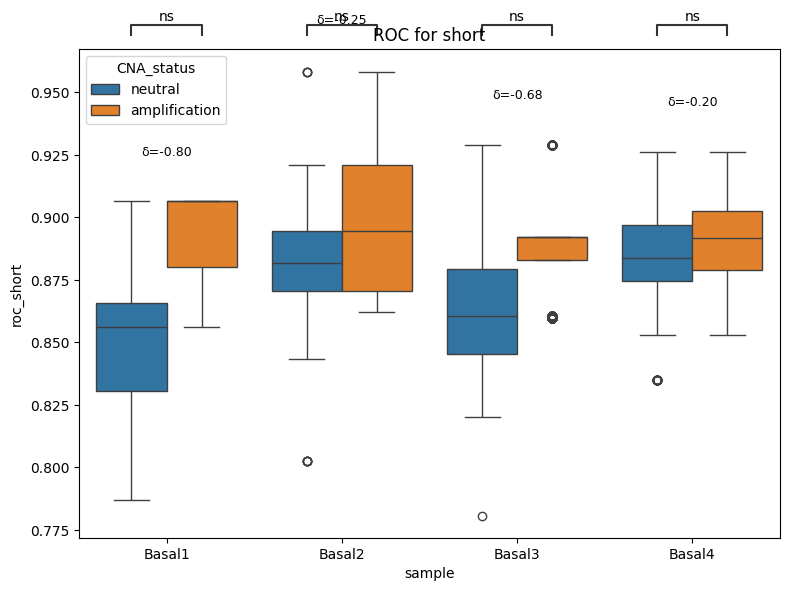

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:5.346e-02
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.000e+00
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:9.999e-01
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:1.625e-18


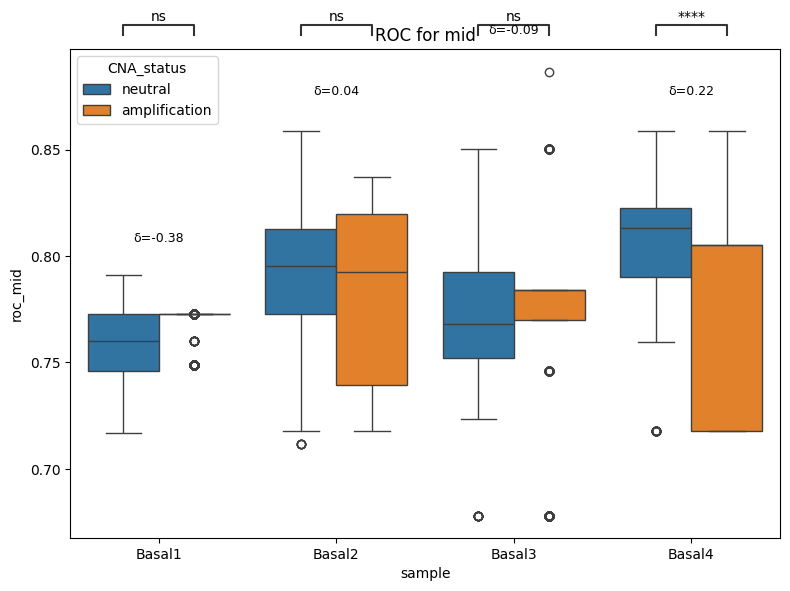

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:7.511e-75
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:9.999e-01
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:9.710e-01
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:1.563e-93


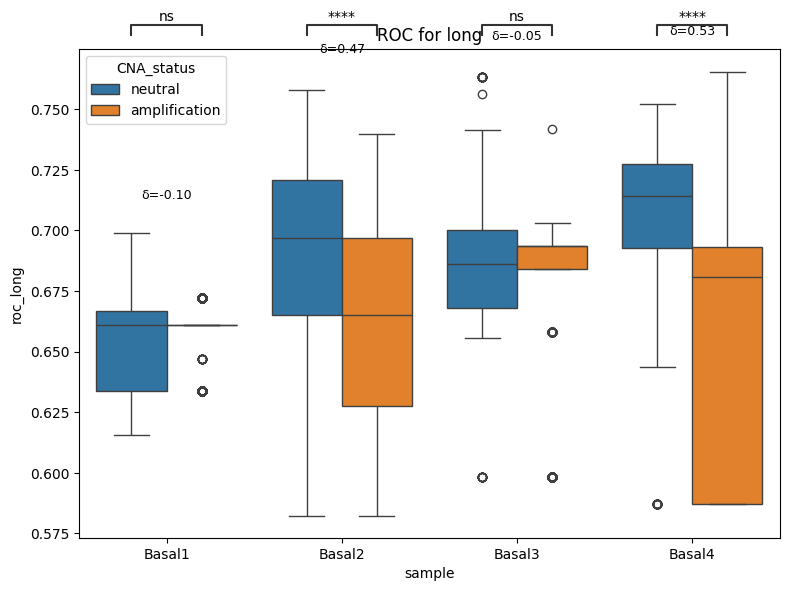

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:3.333e-166
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.000e+00
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:1.000e+00
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:8.478e-61


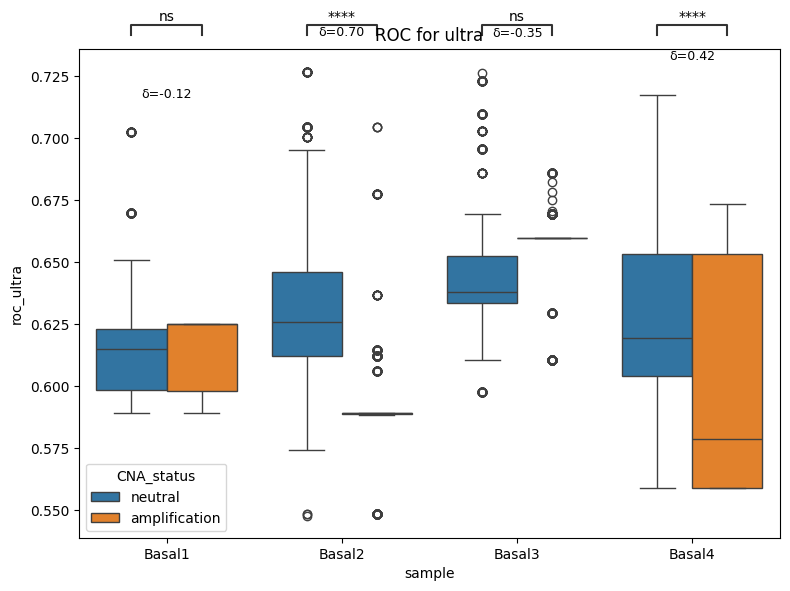

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
#from scipy.stats import brunnermunzel

plot_metric_ranges_sig(all_samples_df, "roc", distance_ranges)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:1.000e+00
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.000e+00
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:1.000e+00
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:1.000e+00


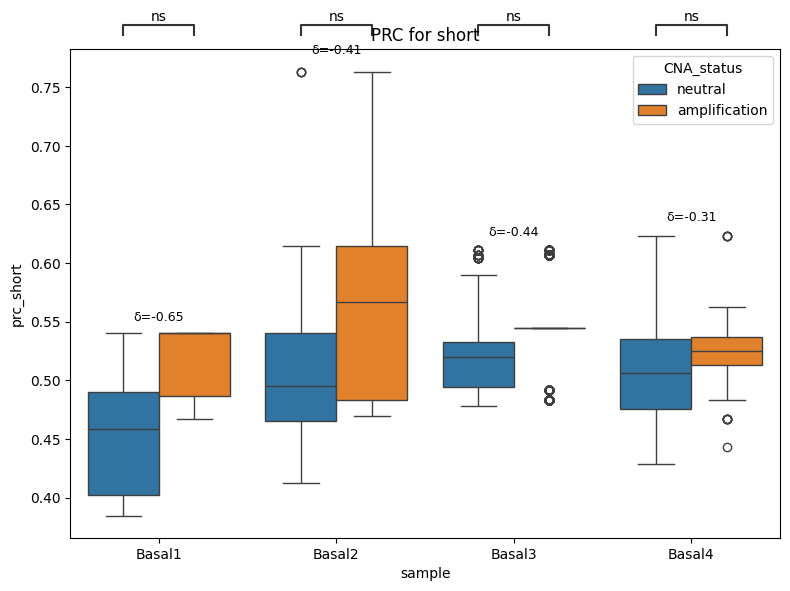

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:4.017e-01
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:7.903e-109
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:9.597e-49
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:1.318e-20


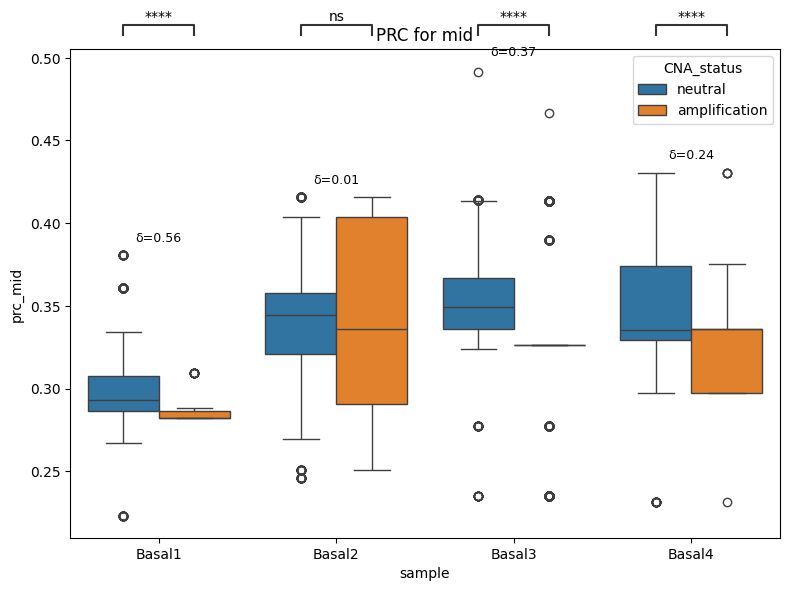

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:1.103e-13
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:6.740e-218
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:1.253e-76
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:2.968e-107


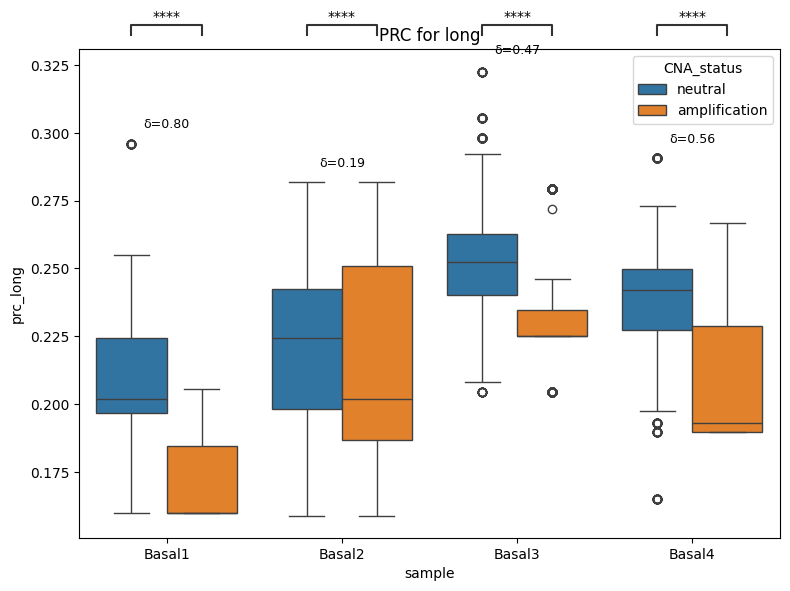

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:4.679e-48
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.000e+00
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:1.000e+00
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:7.168e-53


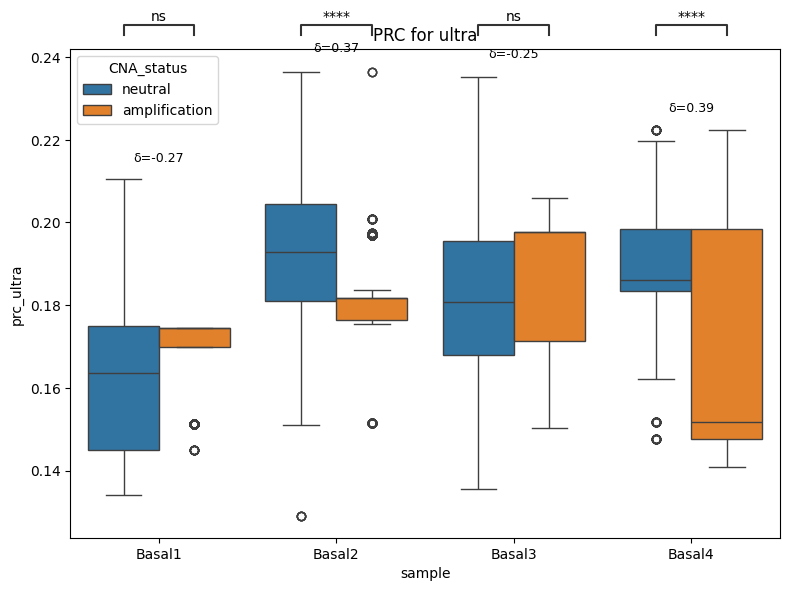

In [58]:
plot_metric_ranges_sig(all_samples_df, "prc", distance_ranges)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:1.000e+00
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.000e+00
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:1.741e-36
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:4.550e-01


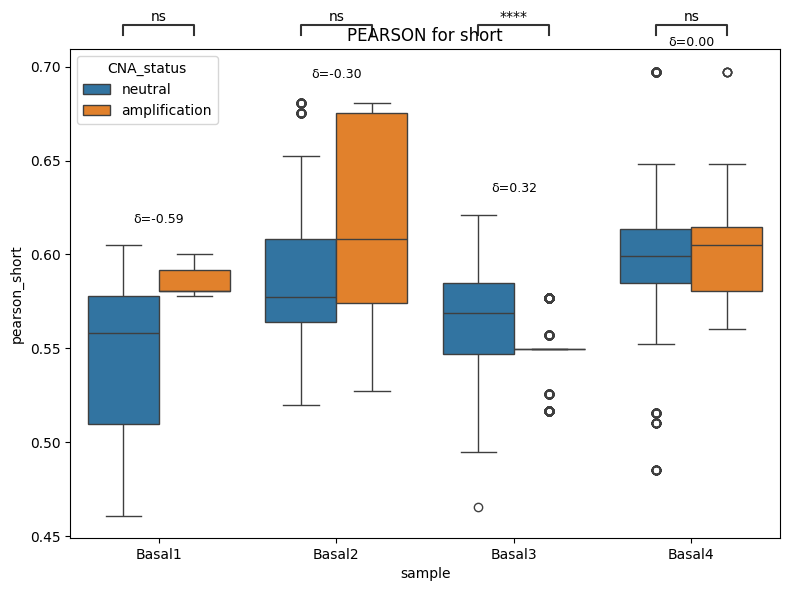

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:8.928e-12
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.960e-20
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:3.731e-178
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:7.058e-28


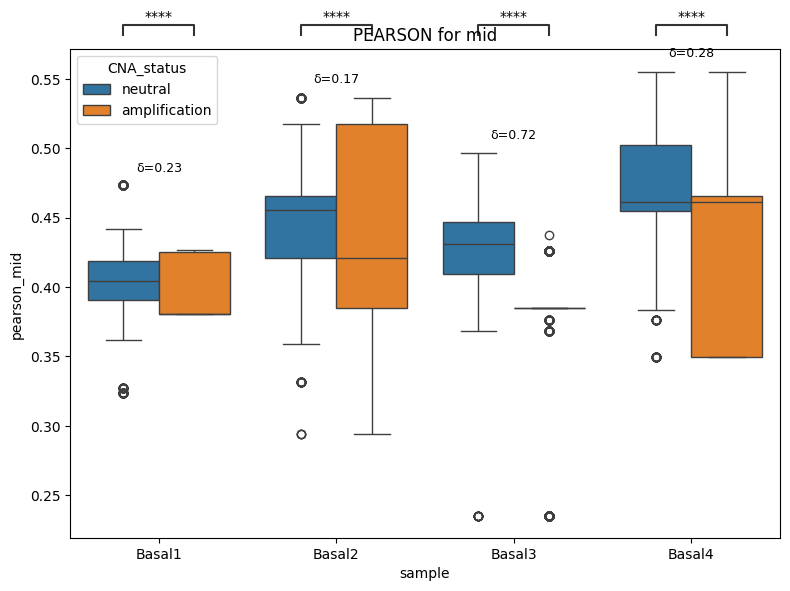

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:1.619e-25
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:1.614e-89
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:1.974e-279
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:1.042e-104


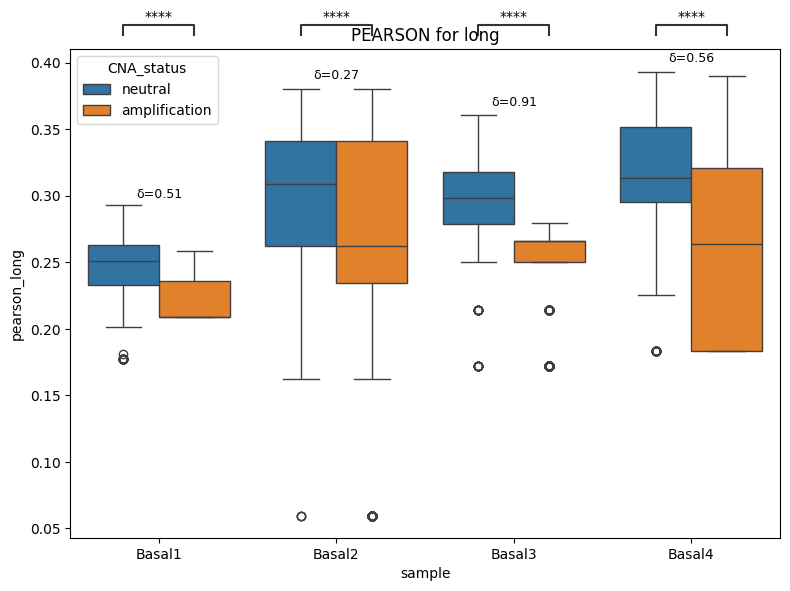

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal2_neutral vs. Basal2_amplification: Custom statistical test, P_val:3.811e-140
Basal1_neutral vs. Basal1_amplification: Custom statistical test, P_val:2.590e-26
Basal3_neutral vs. Basal3_amplification: Custom statistical test, P_val:6.602e-01
Basal4_neutral vs. Basal4_amplification: Custom statistical test, P_val:2.921e-49


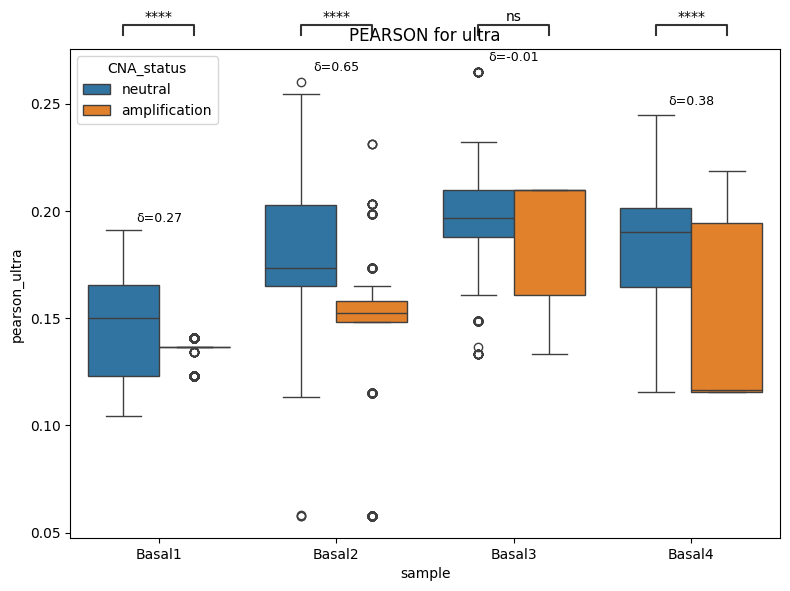

In [59]:
plot_metric_ranges_sig(all_samples_df, "pearson", distance_ranges)

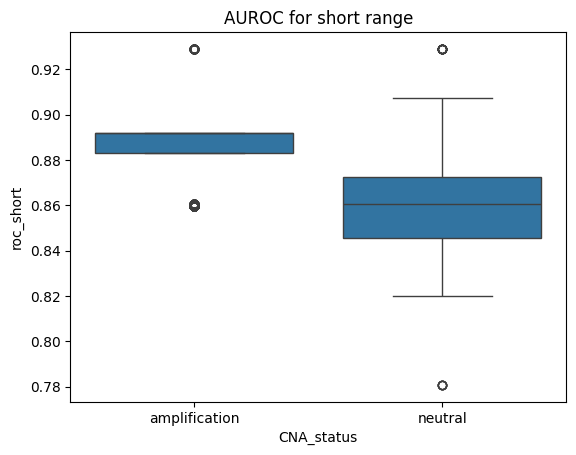

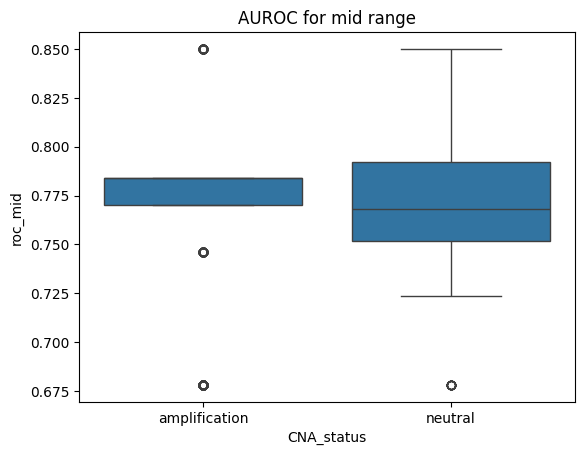

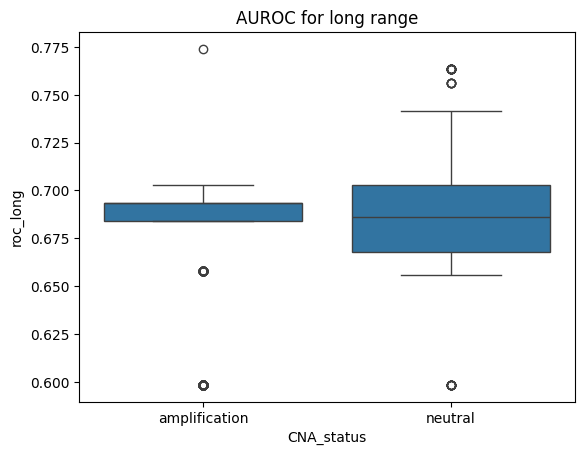

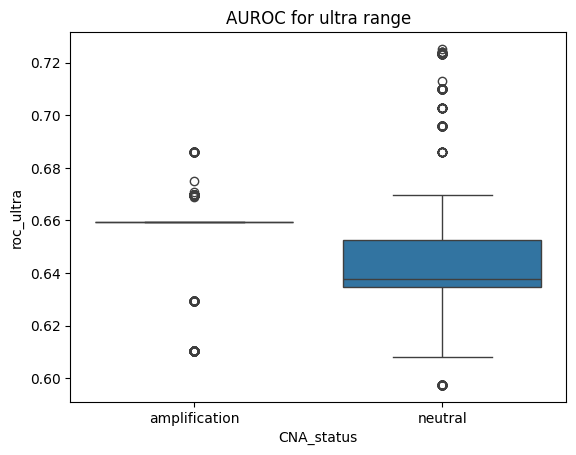

In [121]:
for range_name in distance_ranges.keys():
    sns.boxplot(data=compare_df, x='CNA_status', y=f'roc_{range_name}')
    plt.title(f'AUROC for {range_name} range')
    plt.show()